In [1]:
# Import necessary libraries
import wrds, datetime, calendar, os, glob, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Establish connection to WRDS
db = wrds.Connection(username = 'username')

Loading library list...
Done


In [3]:
taqm_tables = db.list_tables('taqm_2024')

# Print all available taq database tables (acc)
print(*[item for item in taqm_tables if item.__contains__('ctm_2024') and not item.__contains__('luld')])

ctm_2024 ctm_20240102 ctm_20240103 ctm_20240104 ctm_20240105 ctm_20240108 ctm_20240109 ctm_20240110 ctm_20240111 ctm_20240112 ctm_20240116 ctm_20240117 ctm_20240118 ctm_20240119 ctm_20240122 ctm_20240123 ctm_20240124 ctm_20240125 ctm_20240126 ctm_20240129 ctm_20240130 ctm_20240131 ctm_20240201 ctm_20240202 ctm_20240205 ctm_20240206 ctm_20240207 ctm_20240208 ctm_20240209 ctm_20240212 ctm_20240213 ctm_20240214 ctm_20240215 ctm_20240216 ctm_20240220 ctm_20240221 ctm_20240222 ctm_20240223 ctm_20240226 ctm_20240227 ctm_20240228 ctm_20240229 ctm_20240301 ctm_20240304 ctm_20240305 ctm_20240306 ctm_20240307 ctm_20240308 ctm_20240311 ctm_20240312 ctm_20240313 ctm_20240314 ctm_20240315 ctm_20240318 ctm_20240319 ctm_20240320 ctm_20240321 ctm_20240322 ctm_20240325 ctm_20240326 ctm_20240327 ctm_20240328 ctm_20240401 ctm_20240402 ctm_20240403 ctm_20240404 ctm_20240405 ctm_20240408 ctm_20240409 ctm_20240410 ctm_20240411 ctm_20240412 ctm_20240415 ctm_20240416 ctm_20240417 ctm_20240418 ctm_20240419 ctm

In [4]:
# We can simply query data using SQL language
test_query: str = f"""
    SELECT 
        *
    FROM
        taqm_2024.ctm_20240322
    WHERE
        1 = 1 -- Used for simply programming
        AND sym_root = 'SPY'
        AND EXTRACT(HOUR FROM ('2000-01-01 ' || time_m)::timestamp) >= 10
        AND EXTRACT(HOUR FROM ('2000-01-01 ' || time_m)::timestamp) <= 17
    
"""
test_data: pd.DataFrame = db.raw_sql(test_query)
test_data.index = pd.to_datetime(test_data['date'].astype(str) + ' ' + test_data['time_m'].astype(str), format = 'mixed')

In [5]:
test_data['mean_price'] = test_data.price
test_data['median_price'] = test_data.price
test_data = test_data.resample('60S').agg({"mean_price":'mean',"median_price":'median'})

<Axes: >

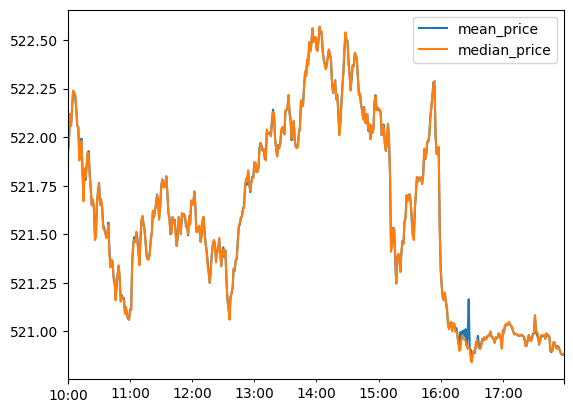

In [6]:
# We see that the mean price can fluctuate at times
test_data.plot()

In [7]:
import psycopg2

class WRDSDataAccess:
    def __init__(self, host, database, username, password):
        self.host = host
        self.database = database
        self.username = username
        self.password = password
        self.connection = None
        self.cursor = None

    def connect(self):
        try:
            self.connection = psycopg2.connect(
                host=self.host,
                database=self.database,
                user=self.username,
                password=self.password
            )
            self.cursor = self.connection.cursor()
            print("Connected to the database")
        except psycopg2.Error as e:
            print("Unable to connect to the database:", e)

    def disconnect(self):
        if self.connection:
            self.cursor.close()
            self.connection.close()
            print("Disconnected from the database")

    def execute_query(self, query):
        try:
            self.cursor.execute(query)
            return self.cursor.fetchall()
        except psycopg2.Error as e:
            print("Error executing query:", e)
            return None

In [8]:
def fetcher(symbol, start_date, end_date, year = 2024):
    lst = []
    start_date = datetime.datetime.strptime(start_date, '%Y-%m-%d')
    end_date = datetime.datetime.strptime(end_date, '%Y-%m-%d')
    current_date = start_date
    while current_date <= end_date:
        lst.append(current_date.strftime('%Y-%m-%d'))
        current_date += datetime.timedelta(days=1)

    
    df = pd.DataFrame()
    try:
        taqm_tables = db.list_tables(f'taqm_{year}')
        for day in lst:
            if f"""ctm_{day.replace('-','')}""" in taqm_tables:
                query = f"""
                    SELECT
                        date, time_m, price
                    FROM
                        taqm_{year}.ctm_{day.replace('-','')}
                    WHERE 
                        1 = 1 -- code cleaning
                        AND sym_root = '{symbol}'
                        AND EXTRACT(HOUR FROM ('2000-01-01 ' || time_m)::timestamp) >= 10
                        AND EXTRACT(HOUR FROM ('2000-01-01 ' || time_m)::timestamp) <= 17
                """
                data = db.raw_sql(query)
                data.index = pd.to_datetime(data['date'].astype(str) + ' ' + data['time_m'].astype(str), format = 'mixed')
                data.index.name = 'Date'
                data = data.drop(columns = ['date','time_m'])
                data['mean_price'] = data.price
                data['median_price'] = data.price
                data = data.resample('60S').agg({"mean_price":'mean',"median_price":'median'})
                df = pd.concat([df,data], ignore_index = False)
            else: pass #print(f'{symbol}: No trades on', day)
    except Exception as e: pass
    return df

def generate_time_list(start_time, end_time, interval_minutes):
    """
    Generates a list of times with a specified interval.

    Args:
    - start_time: Start time in the format 'HH:MM'.
    - end_time: End time in the format 'HH:MM'.
    - interval_minutes: Interval between times in minutes.

    Returns:
    - List of times.
    """
    # Convert start and end times to datetime objects
    start_datetime = datetime.datetime.strptime(start_time, '%H:%M')
    end_datetime = datetime.datetime.strptime(end_time, '%H:%M')

    # Initialize list to store times
    time_list = []

    # Iterate through times and generate list
    current_time = start_datetime
    while current_time <= end_datetime:
        time_list.append(current_time.strftime('%H:%M'))
        current_time += datetime.timedelta(minutes=interval_minutes)

    return time_list

def transform(data, open: str = '09:30', close: str = '16:30', interval_minutes: int = 1):
    mapper = lambda x, y : pd.to_datetime(str(x).split(' ')[0] + ' ' + y)
    time_list = generate_time_list(open, close, interval_minutes)
    new_data = pd.DataFrame(columns = data.resample('1d').last().index.unique(), index = time_list)
    data = data.resample(str(60 * interval_minutes) + 'S').last()
    for col in new_data.columns[:-1]:
        _start, _end = mapper(col, open), mapper(col, close)
        new_data[col] = data[(data.index <= _end) & (data.index >= _start)].values
    return new_data.iloc[:-1].dropna(axis = 1)

In [ ]:
# We to a test run
symbols: list = ['AAPL']
for symbol in symbols:
    if not os.path.exists(os.path.join('data', symbol)): os.makedirs(os.path.join('data', symbol))
    for year in range(2023, 2024):
        try:
            db.list_tables(f'taqm_{year}')
            for month in range(1,2):
                start_date = f'{year}-{month}-1'
                end_date = f'{year}-{month}-{calendar.monthrange(year, month)[1]}'
                data_final = fetcher(symbol, start_date, end_date, year = year)
                data_final.to_csv(
                    os.path.join('data', f'{symbol}//data_{symbol}_{month}_{year}.csv')
                )
        except: pass #print('No data for year', year)

In [9]:
# Lets call the data and check the validity
test_run: pd.DataFrame = pd.read_csv('data//AAPL//data_AAPL_1_2023.csv', parse_dates = True, index_col = 'Date')
test_run.head()

,mean_price,median_price
Date,,
2023-01-03 10:00:00,127.066248,127.0700
2023-01-03 10:01:00,127.149167,127.1500
2023-01-03 10:02:00,126.873441,126.8669
2023-01-03 10:03:00,126.833744,126.8300
2023-01-03 10:04:00,126.622120,126.6200


In [10]:
open = '10:00'
close = '16:00'
interval_minutes = 1
mapper = lambda x, y : pd.to_datetime(str(x).split(' ')[0] + ' ' + y)
time_list = generate_time_list(open, close, interval_minutes)
new_data = pd.DataFrame(columns = test_run.resample('1d').last().index.unique(), index = time_list)
data = test_run.resample(str(60 * interval_minutes) + 'S').last()
for col in new_data.columns[:-1]:
    try:
        _start, _end = mapper(col, open), mapper(col, close)
        new_data[col] = test_run[(test_run.index <= _end) & (test_run.index >= _start)].values
    except: pass

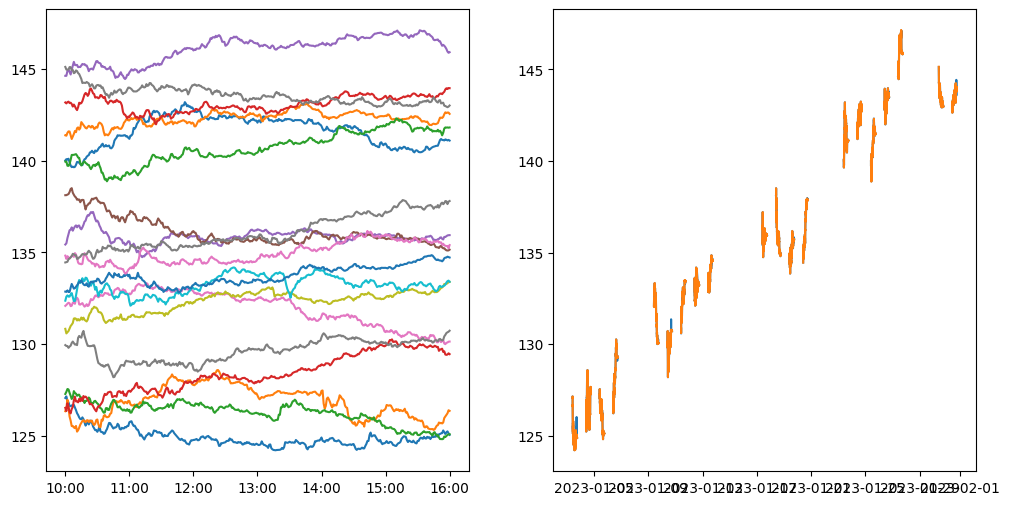

In [11]:
fig, axs = plt.subplots(1,2, figsize = (12, 6))
axs[0].plot(new_data.index, new_data, label = 'Intraday observations')
axs[0].set_xticks(generate_time_list('10:00', '16:00', 60))
axs[1].plot(test_run.astype(float).resample('60S').last(), label = 'Complete data')
plt.show()

In [12]:
# Define parameters for data retrieval
# Note: Adjust 'start_date' and 'end_date' as per your requirements
symbols: list = ['LLY', 'NVO', 'JNJ', 'MRK', 'ABBV', 'AZN', 'NVS', 'RHHBY', 'AMGN', 'PFE', 'MRNA', 'AAPL', 'SPY', 'JPM', 'BAC', 'WFC', 'C', 'USB', 'PNC', 'NU', 'TFC']

In [ ]:
def status(i, N, M, name, year, month): 
    print('Running {:^6}: year = {:^4}, month = {:^2} ({:^5}%) total ({:^5}%)'.format(
        name, year, month, np.round(100 * i / N, 2), np.round(100 * i / M, 2)
    ).ljust(10, ' '), end = '\r')

j = 1
N = 16 * 12
for symbol in symbols:
    i = 1
    M = N * len(symbols)
    if not os.path.exists(os.path.join('data', symbol)): os.makedirs(os.path.join('data', symbol))
    for year in range(2008, 2024):
        for month in range(1,13):
            try:
            
                status(i, N, M, symbol, year, month)
                i += 1
                j += 1
                db.list_tables(f'taqm_{year}')
                start_date = f'{year}-{month}-1'
                end_date = f'{year}-{month}-{calendar.monthrange(year, month)[1]}'
                data_final = fetcher(symbol, start_date, end_date, year = year)
                data_final.to_csv(
                    os.path.join('data', f'{symbol}//data_{symbol}_{month}_{year}.csv')
                )
            except: pass #print('No data for year', year)